In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

sns.set_style("whitegrid")

DATA_PATH = Path("../data/processed")
CHART_PATH = Path("../reports/charts")
CHART_PATH.mkdir(exist_ok=True)

# Load datasets

nav = pd.read_csv(DATA_PATH/"nav_history.csv")
aum = pd.read_csv(DATA_PATH/"aum_data.csv")
sip = pd.read_csv(DATA_PATH/"sip_data.csv")
returns = pd.read_csv(DATA_PATH/"returns_data.csv")
risk = pd.read_csv(DATA_PATH/"risk_metrics.csv")
portfolio = pd.read_csv(DATA_PATH/"portfolio_holdings.csv")
fund_master = pd.read_csv(DATA_PATH/"fund_master.csv")

# Date conversion

nav["date"] = pd.to_datetime(nav["date"])
aum["month"] = pd.to_datetime(aum["month"])
sip["month"] = pd.to_datetime(sip["month"])

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [2]:
nav_plot = nav[
    (nav["date"] >= "2022-01-01") &
    (nav["date"] <= "2026-12-31")
]

fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend (2022-2026)"
)

fig.show()

fig.write_html(
    "../reports/charts/nav_trend.html"
)

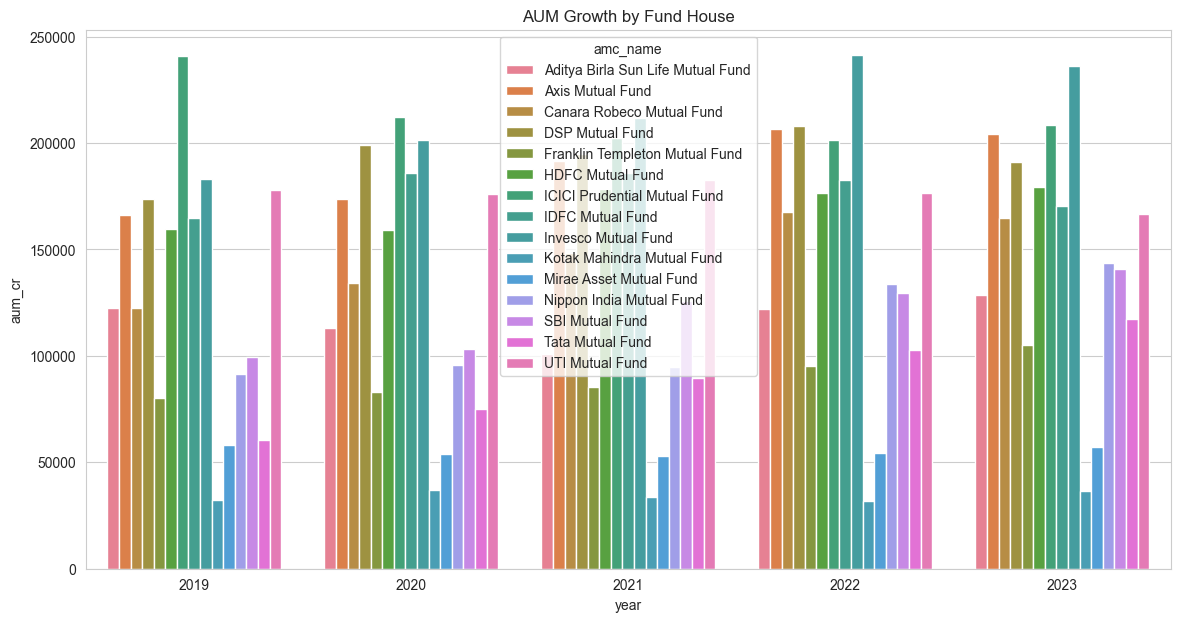

In [3]:
aum["year"] = aum["month"].dt.year

aum_year = (
    aum.groupby(["year","amc_name"])["aum_cr"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14,7))

sns.barplot(
    data=aum_year,
    x="year",
    y="aum_cr",
    hue="amc_name"
)

plt.title("AUM Growth by Fund House")

plt.savefig(
    "../reports/charts/aum_growth.png",
    bbox_inches="tight"
)

plt.show()

In [4]:
sip_monthly = (
    sip.groupby("month")["monthly_sip_amt"]
    .sum()
    .reset_index()
)

fig = px.line(
    sip_monthly,
    x="month",
    y="monthly_sip_amt",
    title="Monthly SIP Trend"
)

fig.add_annotation(
    x=sip_monthly.iloc[-1]["month"],
    y=sip_monthly["monthly_sip_amt"].max(),
    text="₹31,002 Cr"
)

fig.show()

fig.write_html(
    "../reports/charts/sip_trend.html"
)

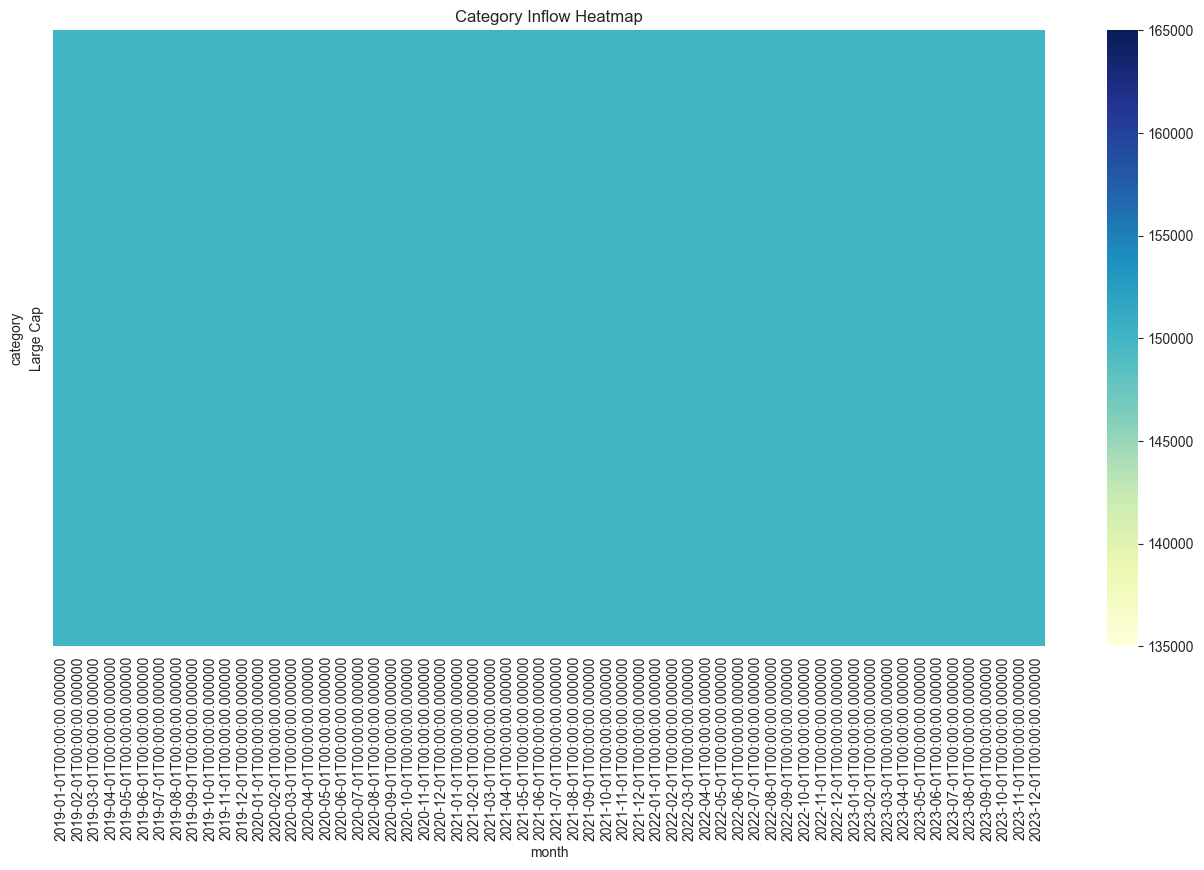

In [5]:
merged = sip.merge(
    fund_master[
        ["scheme_code","category"]
    ],
    on="scheme_code"
)

heat = (
    merged.groupby(
        ["category","month"]
    )["monthly_sip_amt"]
    .sum()
    .unstack()
)

plt.figure(figsize=(16,8))

sns.heatmap(
    heat,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.savefig(
    "../reports/charts/category_heatmap.png"
)

plt.show()

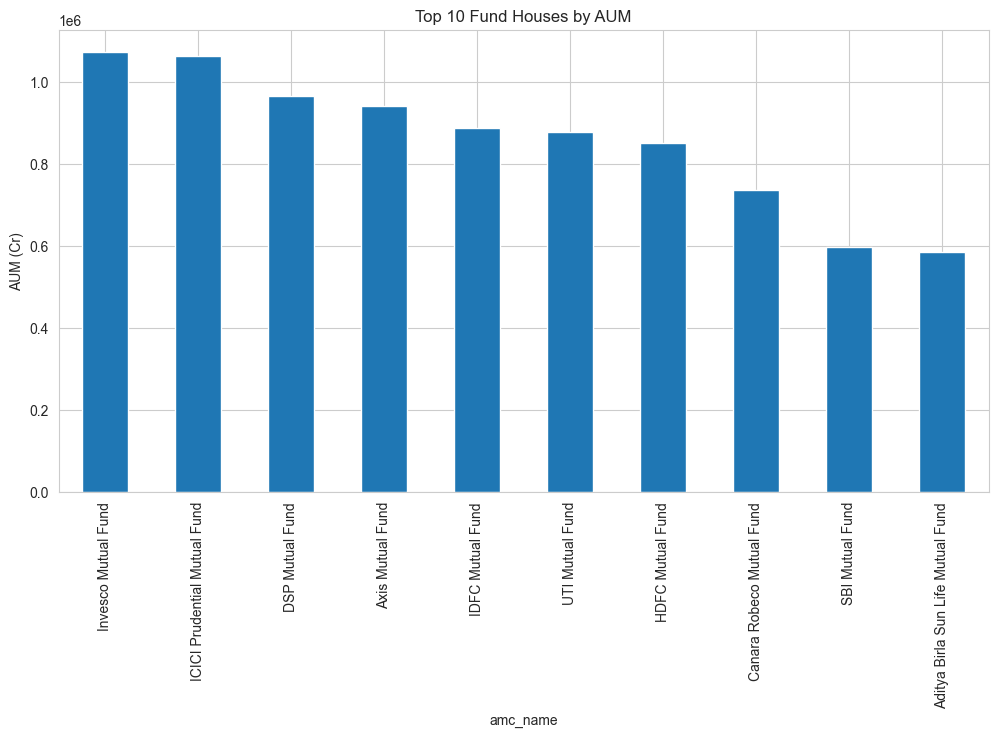

In [6]:
top_amc = (
    aum.groupby("amc_name")["aum_cr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_amc.plot(kind="bar")

plt.title("Top 10 Fund Houses by AUM")

plt.ylabel("AUM (Cr)")

plt.savefig(
    "../reports/charts/top_amc.png"
)

plt.show()

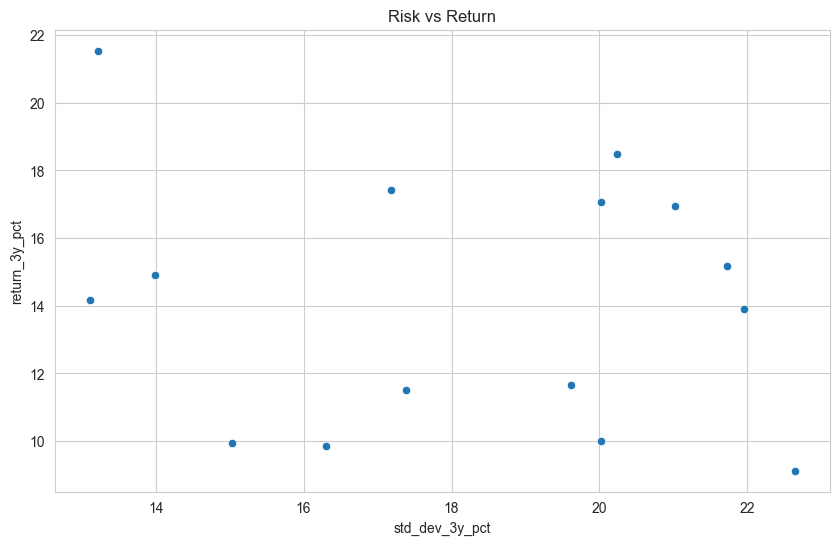

In [7]:
rr = returns.merge(
    risk,
    on="scheme_code"
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rr,
    x="std_dev_3y_pct",
    y="return_3y_pct"
)

plt.title("Risk vs Return")

plt.savefig(
    "../reports/charts/risk_return.png"
)

plt.show()

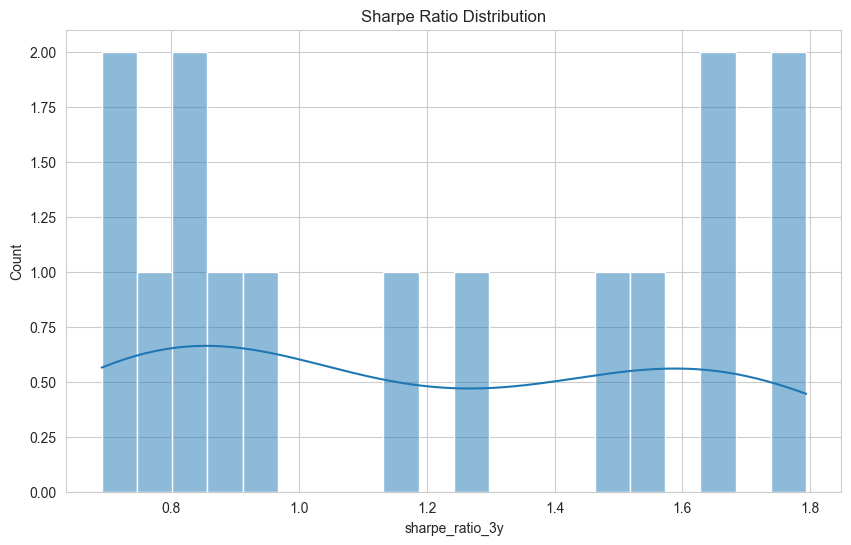

In [8]:
plt.figure(figsize=(10,6))

sns.histplot(
    risk["sharpe_ratio_3y"],
    bins=20,
    kde=True
)

plt.title("Sharpe Ratio Distribution")

plt.savefig(
    "../reports/charts/sharpe_distribution.png"
)

plt.show()

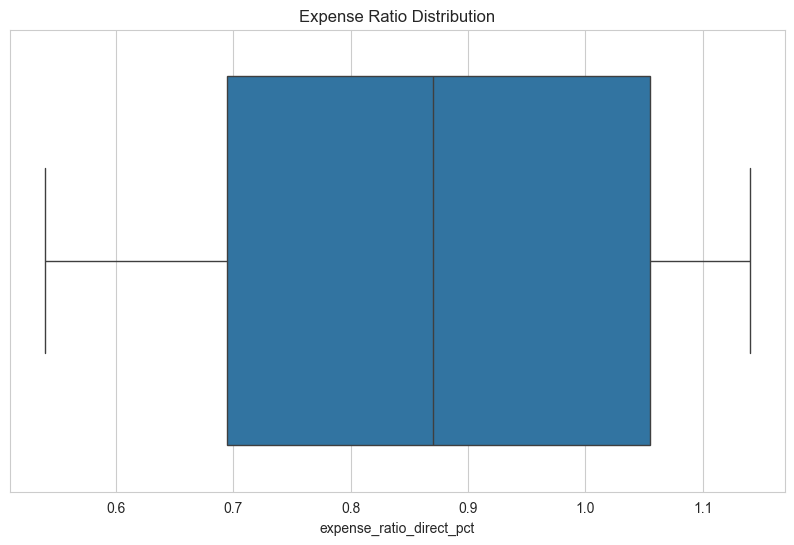

In [9]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="expense_ratio_direct_pct",
    data=pd.read_csv(
        DATA_PATH/"expense_ratio.csv"
    )
)

plt.title("Expense Ratio Distribution")

plt.savefig(
    "../reports/charts/expense_ratio_boxplot.png"
)

plt.show()

In [10]:
sector = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .reset_index()
)

fig = px.pie(
    sector,
    names="sector",
    values="weight_pct",
    hole=0.5,
    title="Sector Allocation"
)

fig.show()

fig.write_html(
    "../reports/charts/sector_allocation.html"
)

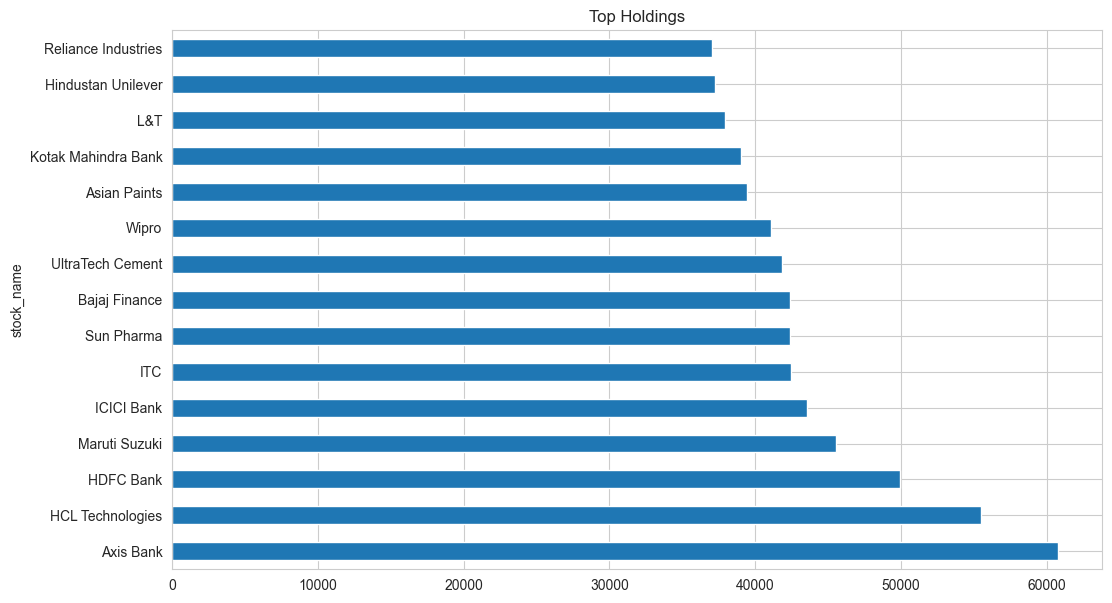

In [11]:
top_holdings = (
    portfolio.groupby("stock_name")
    ["market_value_cr"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,7))

top_holdings.plot(kind="barh")

plt.title("Top Holdings")

plt.savefig(
    "../reports/charts/top_holdings.png"
)

plt.show()

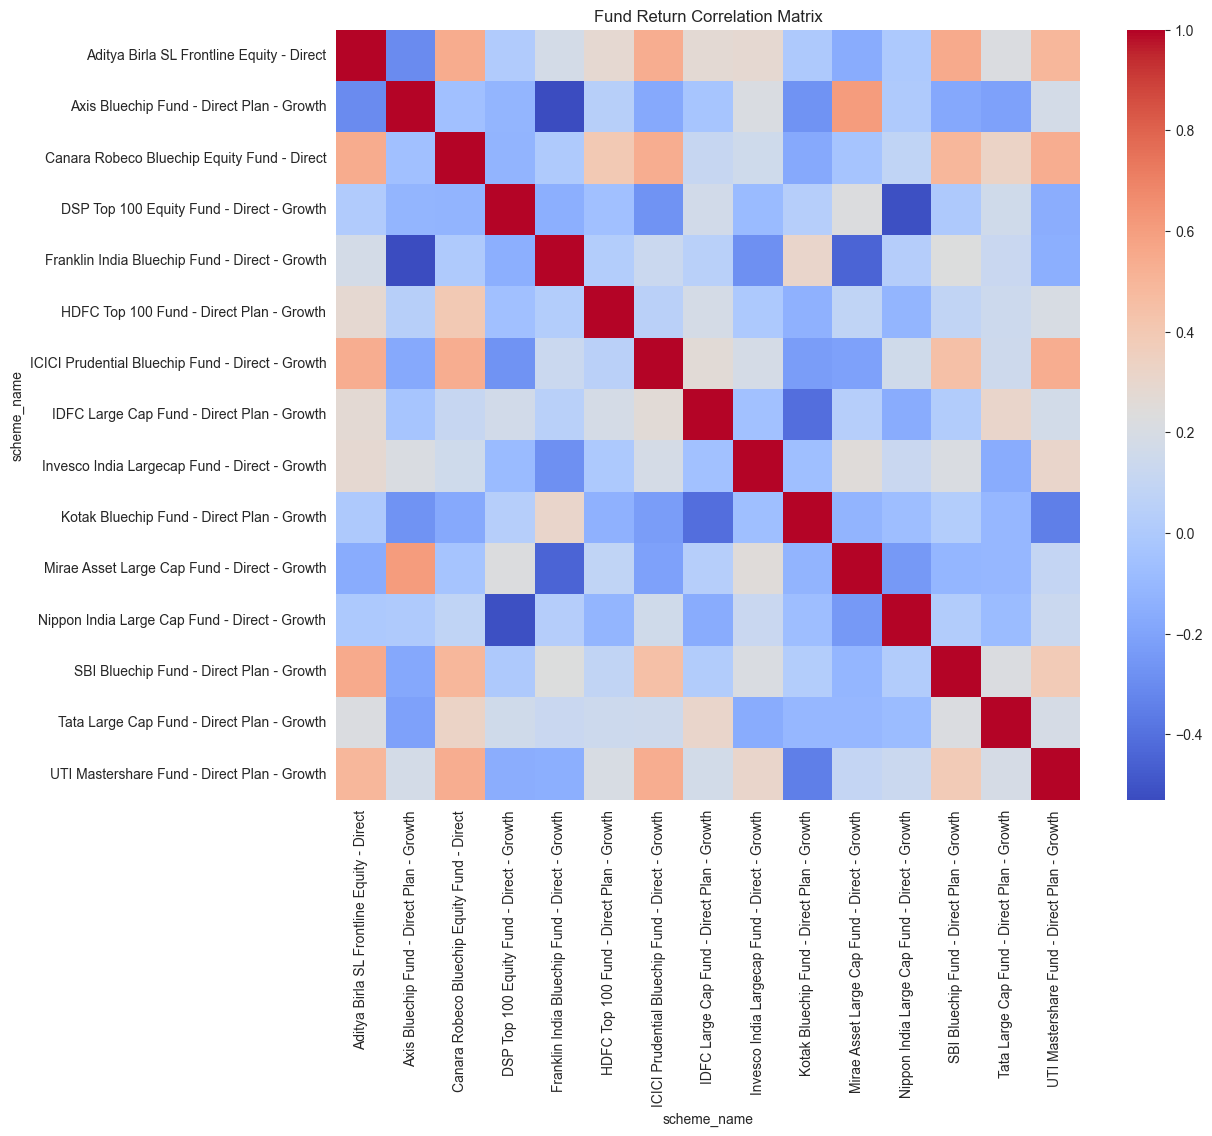

In [12]:
pivot = nav.pivot_table(
    index="date",
    columns="scheme_name",
    values="nav"
)

returns_daily = pivot.pct_change()

corr = returns_daily.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Fund Return Correlation Matrix")

plt.savefig(
    "../reports/charts/correlation_matrix.png"
)

plt.show()

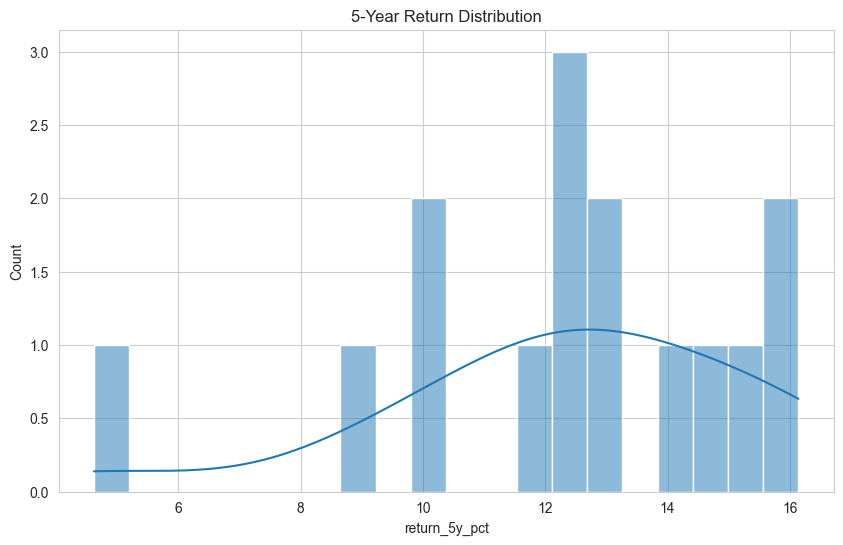

In [13]:
plt.figure(figsize=(10,6))

sns.histplot(
    returns["return_5y_pct"],
    bins=20,
    kde=True
)

plt.title("5-Year Return Distribution")

plt.savefig(
    "../reports/charts/return_distribution.png"
)

plt.show()

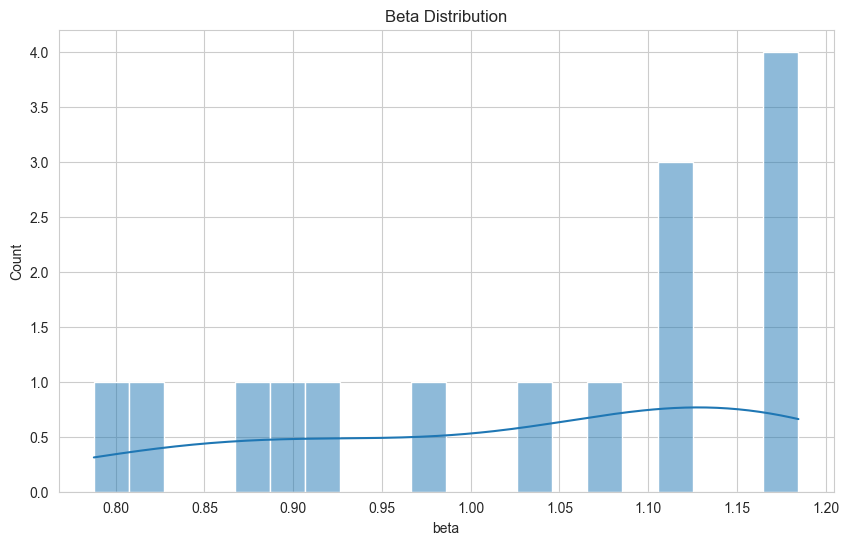

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(
    risk["beta"],
    bins=20,
    kde=True
)

plt.title("Beta Distribution")

plt.savefig(
    "../reports/charts/beta_distribution.png"
)

plt.show()

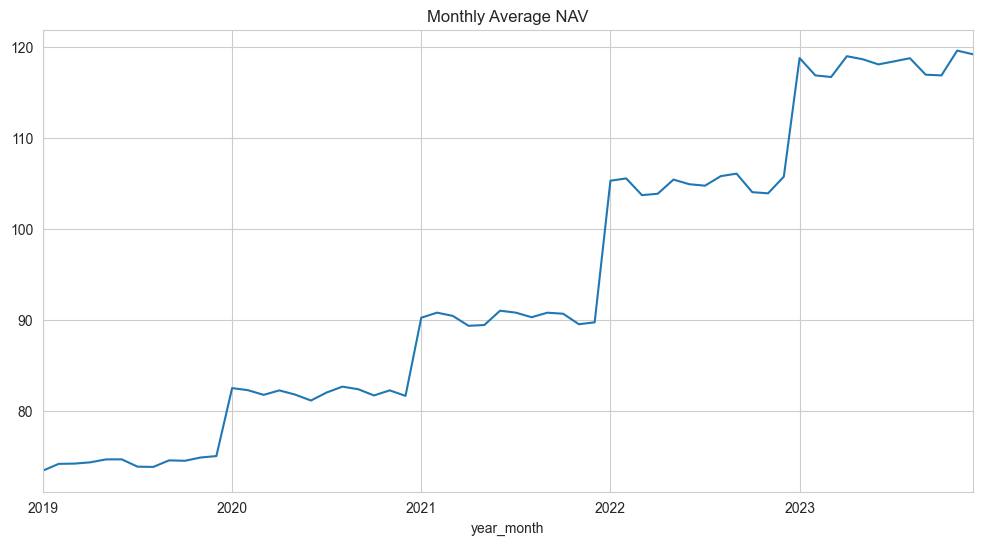

In [15]:
nav["year_month"] = (
    nav["date"]
    .dt.to_period("M")
)

monthly_nav = (
    nav.groupby("year_month")["nav"]
    .mean()
)

monthly_nav.plot(
    figsize=(12,6)
)

plt.title("Monthly Average NAV")

plt.savefig(
    "../reports/charts/monthly_avg_nav.png"
)

plt.show()

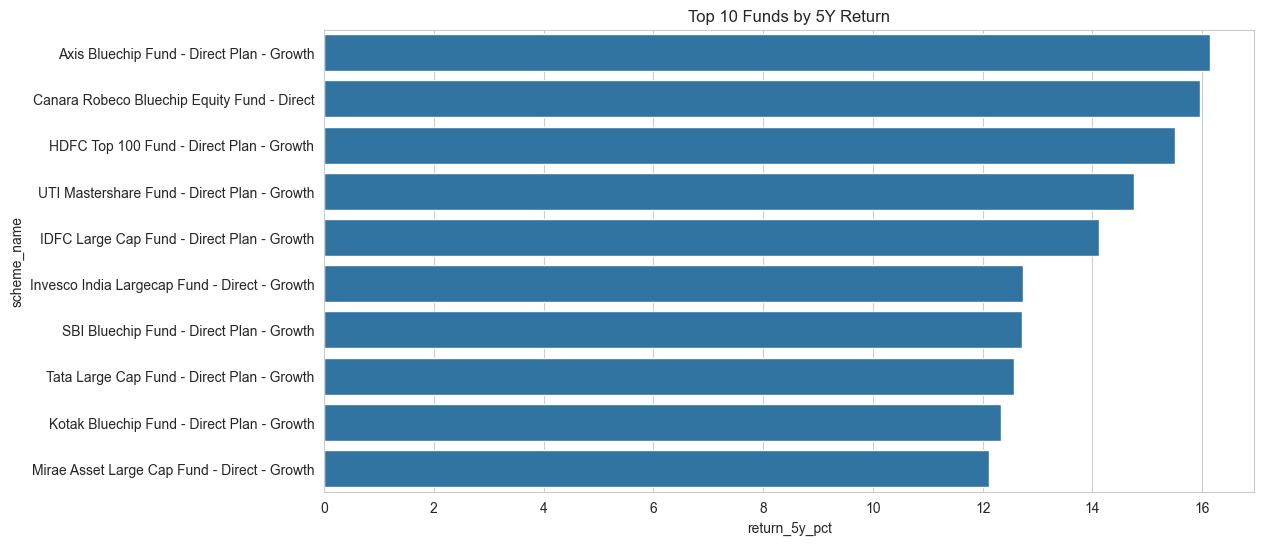

In [16]:
top_returns = (
    returns.sort_values(
        "return_5y_pct",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_returns,
    x="return_5y_pct",
    y="scheme_name"
)

plt.title("Top 10 Funds by 5Y Return")

plt.savefig(
    "../reports/charts/top_returns.png"
)

plt.show()